In [546]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

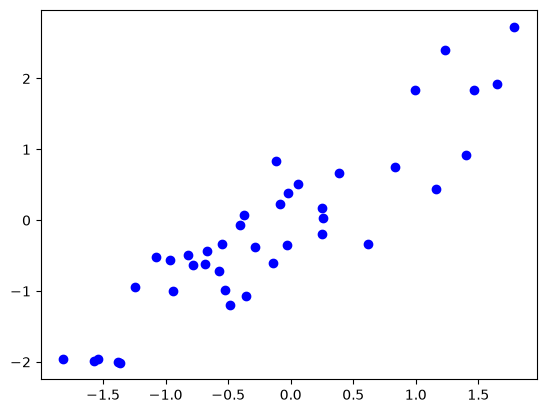

In [547]:
# Experiment 1: training a Neural Network for linear regression
N = 40
x = torch.randn(N, 1)
y = torch.randn(N, 1) * 0.5 + x

plt.plot(x, y, "bo")
plt.show()

In [548]:
ANNReg = nn.Sequential(
    nn.Linear(1, 1), # input layer
    nn.ReLU(),       # non-linear activation function
    nn.Linear(1, 1)  # output layer
)

In [549]:
learning_rate = 0.05
lossfunc = nn.MSELoss()
optimizer = torch.optim.SGD(ANNReg.parameters(), lr=learning_rate)

In [550]:
training_epochs = 500
losses = torch.zeros(training_epochs)

for epoch in range(training_epochs):
    # forward pass
    yHat = ANNReg(x)

    # compute loss
    loss = lossfunc(yHat, y)
    losses[epoch] = loss

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

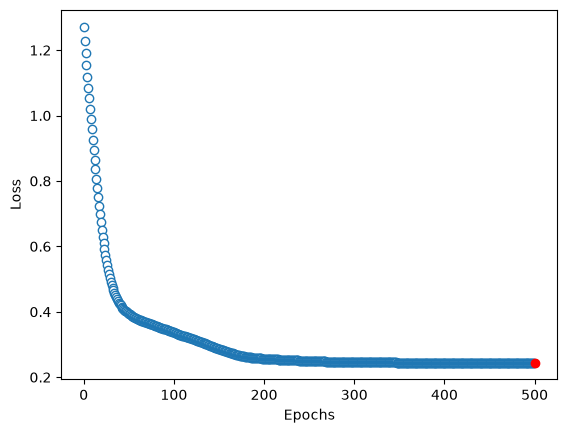

In [551]:
predictions = ANNReg(x)
testloss = (predictions - y).pow(2).mean()

plt.plot(losses.detach(), 'o', markerfacecolor='w', linewidth=.1)
plt.plot(training_epochs, testloss.detach(), 'ro')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

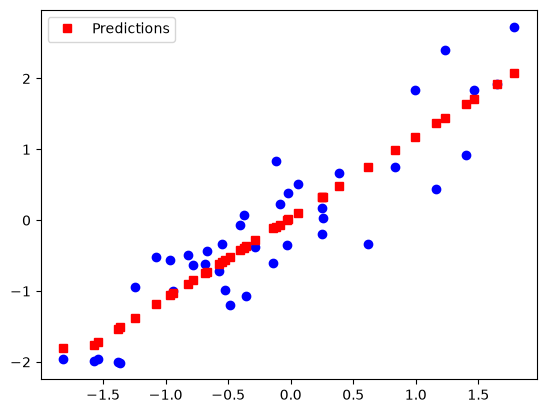

In [552]:
plt.plot(x, y, 'bo')
plt.plot(x, predictions.detach(), 'rs', label='Predictions')
plt.legend()
plt.show()

In [553]:
# Experiment 2: exploring the correlation between slope and model loss/performance

def regression_model(slope):
    N = 50
    x = torch.randn(N, 1)
    y = torch.randn(N, 1) * 0.5 + x * slope

    model = nn.Sequential(
        nn.Linear(1,1),
        nn.ReLU(),
        nn.Linear(1,1)
    )
    learning_rate = 0.05
    lossfunc = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    training_epochs = 500
    losses = torch.zeros(training_epochs)

    for epoch in range(training_epochs):
        yHat = model(x)

        loss = lossfunc(yHat, y)
        losses[epoch] = loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    predictions = model(x)
    finalloss = (predictions - y).pow(2).mean() 
    correlation = np.corrcoef(y.T, predictions.detach().T)[0,1]
    if np.isnan(correlation):
        correlation = 0.0
        
    return correlation, finalloss

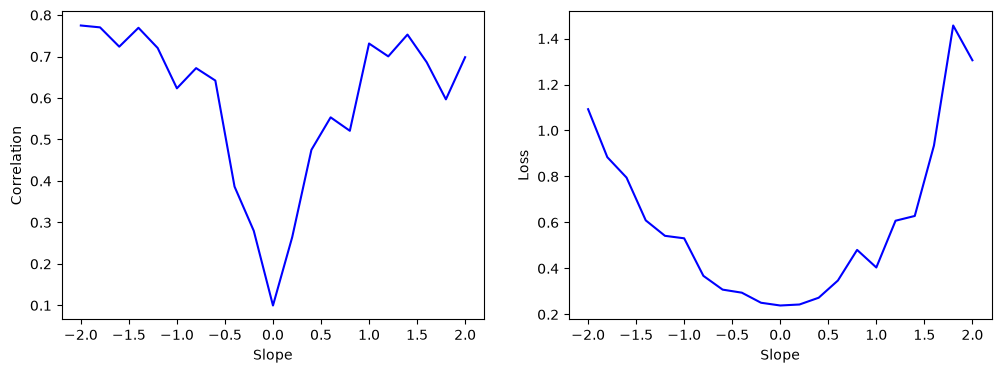

In [554]:
space = torch.linspace(-2, 2, 21)
data = torch.zeros(21, 2)

for i in range(50):
    for idx, s in enumerate(space):
        correlation, loss = regression_model(s)
        data[idx, 0] += correlation
        data[idx, 1] += loss 
        

data /= 50
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(space, data[:,0].detach(), 'b-')
ax[0].set_xlabel("Slope")
ax[0].set_ylabel("Correlation")

ax[1].plot(space, data[:,1].detach(), 'b-')
ax[1].set_xlabel("Slope")
ax[1].set_ylabel("Loss")

plt.show()


In [ ]:
# Observation: While slope values closer to 0 have a smaller loss value, they also have a lower correlation value. 

# Conclusions:

## The losses are not normalized, they are in the scale of the data, so, a larger slope leads to higher variance in the y value. 
## Losses can only be compared on the same data, or on different datasets that are normalized to the same numeric range.

## The closer the slope is to zero, the less effect x has on y. This means the model has less information about y.
## Deep learning models do not predict data values, they learn relationships between values.